This works but not in jupyter notebooks!

Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\254362\254362.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143999  =      0.000 ...  1124.992 secs...
Used Annotations descriptions: [np.str_('videos\\1 excited\\1 motorsports\\kenMiles.mp4,videos\\1 excited\\1 motorsports\\kenMiles.mp4,-1,1'), np.str_('videos\\2 happy\\scooby.mp4,videos\\2 happy\\scooby.mp4,-1,4'), np.str_('videos\\3 motivated\\motivationalAuthor.mp4,videos\\3 motivated\\motivationalAuthor.mp4,-1,7'), np.str_('videos\\4 relaxed\\3 general\\asmr.mkv,videos\\4 relaxed\\3 general\\asmr.mkv,-1,10'), np.str_('videos\\5 sad\\1 animals\\saddogs.mp4,videos\\5 sad\\1 animals\\saddogs.mp4,-1,13'), np.str_('videos\\6 horror\\conjuring.mp4,videos\\6 horror\\conjuring.mp4,-1,16'), np.str_('videos\\7 disgusted\\trainspotting.mp4,videos\\7 disgusted\\trainspotting.mp4,-1,19'), np.str_('videos\\8 angry\\1 animals\\angrydogs.mp4,videos\\8 angry\\1 anima

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\mne\viz\utils.py:158: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


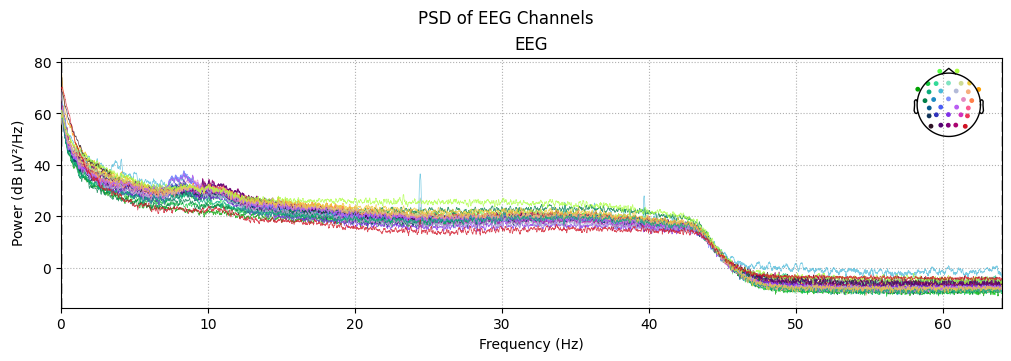

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# Read your EDF file
raw = mne.io.read_raw_edf(
    r'EDF+\712563\712563.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )

events, event_dict = mne.events_from_annotations(raw, regexp='^(?=.*videos)(?!.*neutralVideo)')
# Set up the 10-20 montage
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')
epochs = mne.Epochs(raw, events, event_dict, -30, 60, baseline=(-30, 0), preload=True).pick_types(eeg=True)
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']
psd_channels = ['Cz', 'Fz', 'Fp1', 'Fp2', 'C3', 'C4', 'Pz', 'Oz', 'P3', 'P4']

raw.set_eeg_reference('average', projection=True)  # set EEG average reference
# epochs.plot(picks=eeg_channels, n_epochs=2, block=True)
# epochs.plot_psd(picks=psd_channels, block=True)
psd_fig = epochs.copy().crop(-30, 60).plot_psd(picks=eeg_channels, n_jobs=1)
print('Epochs',epochs)
psd_fig.suptitle('PSD of EEG Channels')
plt.show()

In [1]:
## Didn't work but close:

## Works but not sure why only 5 are graphed

Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\712563\712563.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 139135  =      0.000 ...  1086.992 secs...
Used Annotations descriptions: [np.str_('videos\\1 excited\\1 motorsports\\kenMiles.mp4,videos\\1 excited\\1 motorsports\\kenMiles.mp4,-1,1'), np.str_('videos\\2 happy\\scooby.mp4,videos\\2 happy\\scooby.mp4,-1,4'), np.str_('videos\\3 motivated\\motivationalAuthor.mp4,videos\\3 motivated\\motivationalAuthor.mp4,-1,7'), np.str_('videos\\4 relaxed\\3 general\\asmr.mkv,videos\\4 relaxed\\3 general\\asmr.mkv,-1,10'), np.str_('videos\\5 sad\\3 general\\ChampDeath.mp4,videos\\5 sad\\3 general\\ChampDeath.mp4,-1,13'), np.str_('videos\\6 horror\\conjuring.mp4,videos\\6 horror\\conjuring.mp4,-1,16'), np.str_('videos\\7 disgusted\\trainspotting.mp4,videos\\7 disgusted\\trainspotting.mp4,-1,19'), np.str_('videos\\8 angry\\2 general\\thepiano.mp4,videos\\8 angry\\2 

C:\Users\Admin\AppData\Local\Temp\ipykernel_6396\3465009757.py:28: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw)


Selecting by number: 20 components
Fitting ICA took 3.5s.
Not setting metadata
8 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 8 events and 7681 original time points ...
0 bad epochs dropped
    Using multitaper spectrum estimation with 7 DPSS windows
Not setting metadata
543 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
543 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
543 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
543 matching events found
No baseline correction applied
0 projection items activated
Not setting metadata
543 matching events found
No baseline correction applied
0 projection items activated


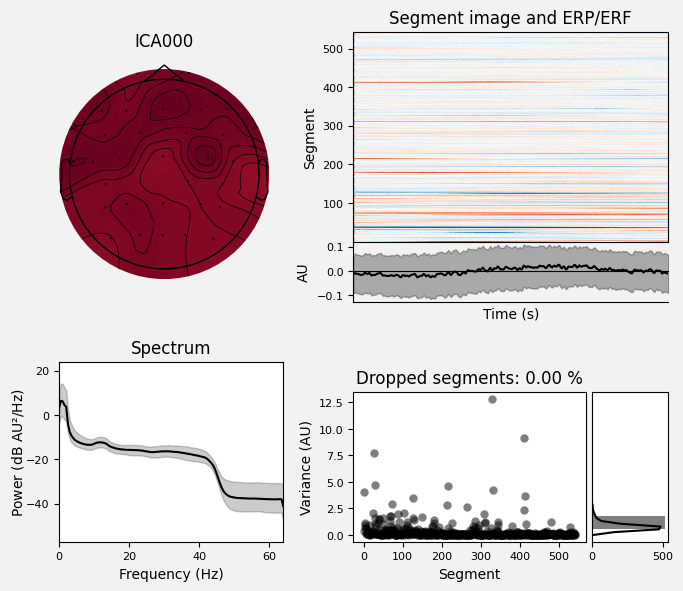

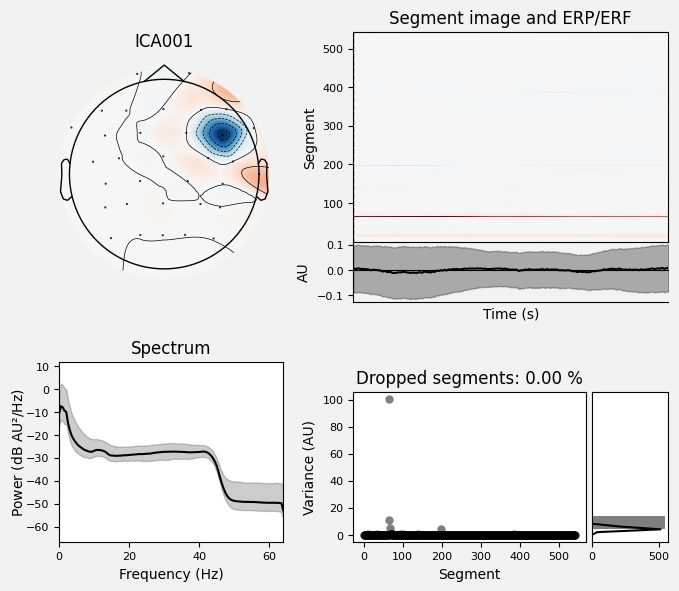

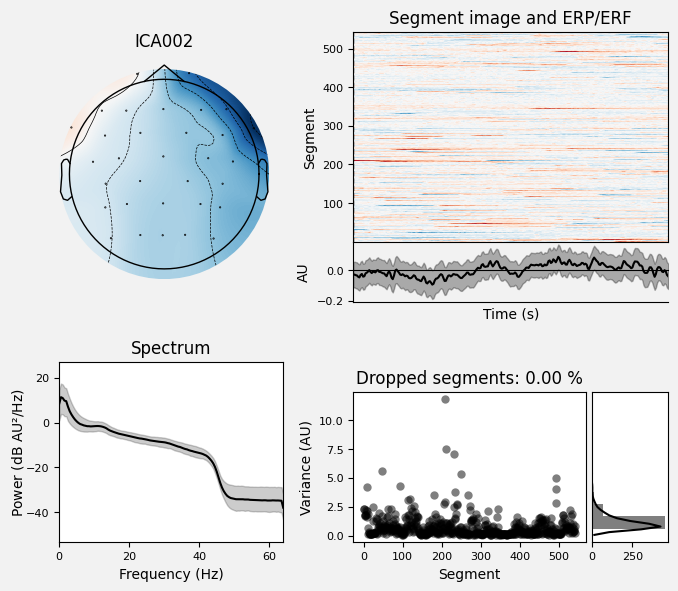

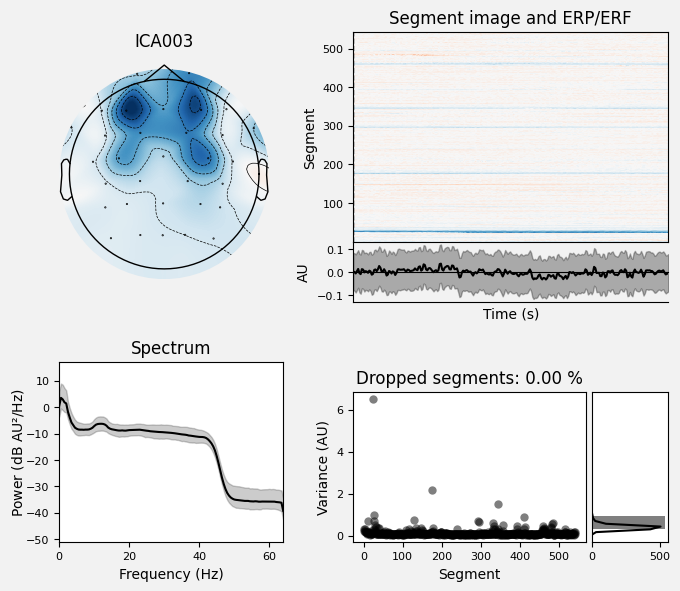

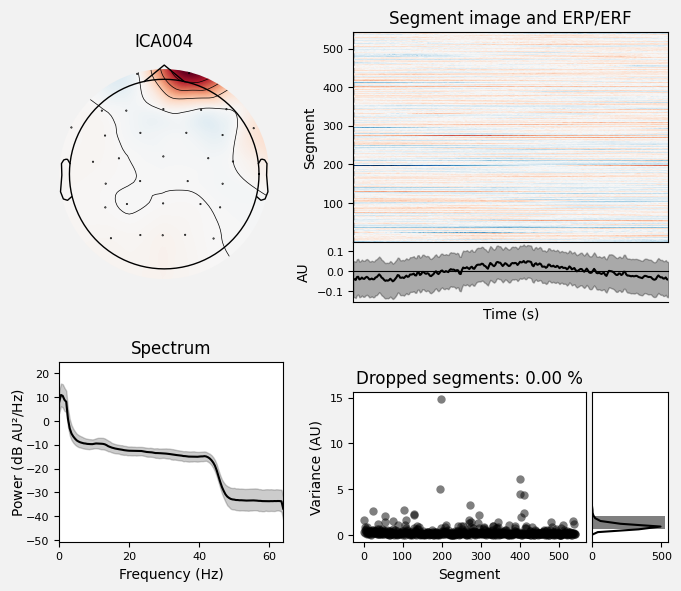

[<Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>,
 <Figure size 700x600 with 6 Axes>]

In [4]:
import mne
import numpy as np
import matplotlib.pyplot as plt
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']

# Read your EDF file
raw = mne.io.read_raw_edf(
    r'EDF+\712563\712563.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )


events, event_dict = mne.events_from_annotations(raw, regexp='^(?=.*videos)(?!.*neutralVideo)')
montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')

# Explicitly pick EEG channels
eeg_picks = mne.pick_types(raw.info, eeg=True)
# Define EEG channels
# set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=20, random_state=97, max_iter=800)
ica.fit(raw)
ica.exclude = [1, 2]  # details on how we picked these are omitted here
# # Create epochs with a duration of 60 seconds
epochs = mne.Epochs(raw, events, event_dict, tmin=-30, tmax=30, baseline=(-30, 0), preload=True)[0:3]
ica.plot_properties(raw)
# # Create epochs with a duration of 60 seconds
# epochs = mne.Epochs(raw, events, event_dict, tmin=-30, tmax=30, baseline=(-30, 0), preload=True)

# # Set EEG average reference
# epochs.set_eeg_reference('average', projection=True)

# # Calculate the start time for the evoked response (30 seconds after the epoch)
# start_time = -30 + 30

# for idx, evoked in enumerate(epochs.iter_evoked()):
#     # Get channel positions from raw.info
#     pos = mne.channels.find_layout(raw.info).pos
    
#     # Plot PSD topomap for each evoked response
#     psd_fig = mne.viz.plot_topomap(evoked, show=False, sensors=True, res=64, pos=pos)
#     psd_fig.suptitle(f'PSD Topomap of EEG Channels (Evoked {idx})')
#     plt.show()


## Works but I have no idea why only 5 graphs all the time

### Finally was able to fix the issue:

In [2]:
import mne
eeg_channels = ['Cz', 'Fz', 'Fp1', 'F7', 'F3', 'FC1', 'C3', 'FC5', 'FT9', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO9', 'O1', 'Pz', 'Oz', 'O2', 'PO10', 'P8', 'P4', 'CP2', 'CP6', 'T8', 'FT10', 'FC6', 'C4', 'FC2', 'F4', 'F8', 'Fp2']

# Read your EDF file
raw = mne.io.read_raw_edf(
    r'EDF+\712563\712563.edf',
    #eog=['Fp1', 'Fp2'], # Define eog channels!  I suggest trying making a copy of these as eog1 and eog2 ##NOTE: YOU MUST watch the capitalization!
    misc=None, # List of channel names to be considered as miscellaneous (MISC) channels.
    stim_channel=None,  # Set to None if you don't have a stim channel
    exclude=['TimestampS', 'TimestampMs', 'OrTimestampS', 'OrTimestampMs', 'Counter', 'Interpolated', 'HighBitFlex', 'SaturationFlag', 'RawCq', 'Battery', 'BatteryPercent', 'MarkerHardware', 'CQ.Cz', 'CQ.Fz', 'CQ.Fp1', 'CQ.F7', 'CQ.F3', 'CQ.FC1', 'CQ.C3', 'CQ.FC5', 'CQ.FT9', 'CQ.T7', 'CQ.CP5', 'CQ.CP1', 'CQ.P3', 'CQ.P7', 'CQ.PO9', 'CQ.O1', 'CQ.Pz', 'CQ.Oz', 'CQ.O2', 'CQ.PO10', 'CQ.P8', 'CQ.P4', 'CQ.CP2', 'CQ.CP6', 'CQ.T8', 'CQ.FT10', 'CQ.FC6', 'CQ.C4', 'CQ.FC2', 'CQ.F4', 'CQ.F8', 'CQ.Fp2', 'CQ.Overall', 'EQ.SampleRateQua', 'EQ.OVERALL', 'EQ.Cz', 'EQ.Fz', 'EQ.Fp1', 'EQ.F7', 'EQ.F3', 'EQ.FC1', 'EQ.C3', 'EQ.FC5', 'EQ.FT9', 'EQ.T7', 'EQ.CP5', 'EQ.CP1', 'EQ.P3', 'EQ.P7', 'EQ.PO9', 'EQ.O1', 'EQ.Pz', 'EQ.Oz', 'EQ.O2', 'EQ.PO10', 'EQ.P8', 'EQ.P4', 'EQ.CP2', 'EQ.CP6', 'EQ.T8', 'EQ.FT10', 'EQ.FC6', 'EQ.C4', 'EQ.FC2', 'EQ.F4', 'EQ.F8', 'EQ.Fp2', 'MOT.TimestampS', 'MOT.TimestampMs', 'MOT.OrTimestampS', 'MOT.OrTimestampM', 'MOT.CounterMems', 'MOT.Interpolated', 'MOT.Q0', 'MOT.Q1', 'MOT.Q2', 'MOT.Q3', 'MOT.AccX', 'MOT.AccY', 'MOT.AccZ', 'MOT.MagX', 'MOT.MagY', 'MOT.MagZ'],  # Exclude channels you don't want
    preload=True,  # Preload data into memory to speed things up
    infer_types=True,  # Infer channel types from names
    verbose=True  # Set verbosity / output messages
    )

montage = mne.channels.make_standard_montage('standard_1020')
raw.set_montage(montage, on_missing='ignore')

# Apply preprocessing steps
raw.set_eeg_reference('average', projection=True)  # set EEG average reference
raw.filter(l_freq=0.5, h_freq=40)  # Apply band-pass filter

# Read events from annotations
events, event_dict = mne.events_from_annotations(raw, regexp='^(?=.*videos)(?!.*neutralVideo)')

# Set up and fit the ICA
ica = mne.preprocessing.ICA(n_components=32, random_state=97, max_iter=800)
ica.fit(raw)

# Exclude some components (for illustration purposes)
test = input('What events to exclude? Edit your code below!')
# ica.exclude =   None

# # Apply ICA to the data
# ica.apply(raw)

# Pick the first three events for visualization
epochs = mne.Epochs(raw, events, event_dict, tmin=-30, tmax=30, baseline=(-30, 0), preload=True)



Extracting EDF parameters from r:\FINAL_EDF_REPO\EDF_analysis\Archive\EDF+\254362\254362.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 143999  =      0.000 ...  1124.992 secs...
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Selecting by number: 32 components
Fitting ICA took 11.3s.
Not setting metadata
8 matching events found
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 1)
1 projection items activated
Using data from preloaded Raw for 8 events and 7681 original time points ...
0 bad epochs dropped


In [4]:
dir(mne.preprocessing)

['EOGRegression',
 'ICA',
 'Xdawn',
 'annotate_amplitude',
 'annotate_break',
 'annotate_movement',
 'annotate_muscle_zscore',
 'annotate_nan',
 'compute_average_dev_head_t',
 'compute_bridged_electrodes',
 'compute_current_source_density',
 'compute_fine_calibration',
 'compute_maxwell_basis',
 'compute_proj_ecg',
 'compute_proj_eog',
 'compute_proj_hfc',
 'corrmap',
 'cortical_signal_suppression',
 'create_ecg_epochs',
 'create_eog_epochs',
 'equalize_bads',
 'eyetracking',
 'find_bad_channels_lof',
 'find_bad_channels_maxwell',
 'find_ecg_events',
 'find_eog_events',
 'fix_stim_artifact',
 'get_score_funcs',
 'ica_find_ecg_events',
 'ica_find_eog_events',
 'ieeg',
 'infomax',
 'interpolate_bridged_electrodes',
 'maxwell_filter',
 'maxwell_filter_prepare_emptyroom',
 'nirs',
 'oversampled_temporal_projection',
 'peak_finder',
 'read_eog_regression',
 'read_fine_calibration',
 'read_ica',
 'read_ica_eeglab',
 'realign_raw',
 'regress_artifact',
 'write_fine_calibration']